# 04 · Report Figures

This notebook generates clean figures and summary tables for the final report and presentation of the Komoot trail recommender project.

It is intentionally separated from the main project notebooks so that the report/presentation work can continue in parallel without modifying:

- `01_data_exploration.ipynb`
- `02_task1_nlp.ipynb`
- `03_task2_recommender.ipynb`

The notebook reads the processed dataset `trails.pkl` and exports figures to `report/figures/` and tables to `report/tables/`.

In [1]:
from pathlib import Path
from collections import Counter
import ast
import json
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files
from pathlib import Path
import shutil

# Upload trails.pkl
uploaded = files.upload()

# Create data folder
Path("/content/data").mkdir(parents=True, exist_ok=True)

if "trails.pkl" in uploaded:
    shutil.move("/content/trails.pkl", "/content/data/trails.pkl")
    print("trails.pkl uploaded and moved to /content/data/trails.pkl")
else:
    print("Please upload a file named trails.pkl")

Saving trails2.pkl to trails2.pkl
Please upload a file named trails.pkl


## 1. Path configuration

In [4]:
from pathlib import Path

# DATA_PATH = Path("/content/data/trails.pkl")
DATA_PATH = Path("/content/trails2.pkl")

if not DATA_PATH.exists():
    raise FileNotFoundError("trails.pkl not found at /content/data/trails.pkl")

PROJECT_ROOT = Path("/content")

FIG_DIR = PROJECT_ROOT / "report" / "figures"
TABLE_DIR = PROJECT_ROOT / "report" / "tables"

FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Using dataset: {DATA_PATH}")
print(f"Figures will be saved to: {FIG_DIR}")
print(f"Tables will be saved to: {TABLE_DIR}")

Using dataset: /content/trails2.pkl
Figures will be saved to: /content/report/figures
Tables will be saved to: /content/report/tables


## 2. Load dataset

In [90]:
df = pd.read_pickle(DATA_PATH)

print(f"Dataset shape: {df.shape[0]:,} trails × {df.shape[1]:,} columns")
display(df.head(3))

Dataset shape: 5,642 trails × 45 columns


,tour_id,url,source,share_url,name,name_original,sport,tour_type,difficulty,difficulty_technical,...,categories,tags,rating_score,rating_count,visitors,author_name,author_id,created_at,changed_at,scraped_at
2,e1000043794,https://www.komoot.com/smarttour/e1000043794,komoot,https://www.komoot.com/smarttour/e1000043794/c...,Cabezón Valley Loop,Cabezón de la Sal - La Cocina – circular por e...,mtb,editorial_tour,moderate,dm#t2,...,"[bridge, challenging, climb, intermediate, riv...",[],3.000000,2,4,komoot,komoot,2022-12-28T16:29:34.665Z,2026-02-26T19:29:23.886Z,2026-04-28T14:18:52.970602+00:00
7,e1000263300,https://www.komoot.com/smarttour/e1000263300,komoot,https://www.komoot.com/smarttour/e1000263300/l...,Lac de Clarens Loop from Casteljaloux,Tour du Lac de Clarens – boucle à Casteljaloux,hike,editorial_tour,moderate,t2,...,"[beach, facilities, family_friendly, forest, l...",[],4.000000,1,8,komoot,komoot,2022-12-29T05:11:20.024Z,2026-02-26T19:29:26.579Z,2026-04-27T12:24:10.890329+00:00
9,e1000271422,https://www.komoot.com/smarttour/e1000271422,komoot,https://www.komoot.com/smarttour/e1000271422/p...,Puig de ses Torretes Loop,Puig de ses Torretes y cala Sol d'en Serrà — c...,hike,editorial_tour,moderate,t2,...,"[beach, challenging, family_friendly, intermed...",[],4.406393,219,799,komoot,komoot,2022-12-29T06:30:00.624Z,2026-02-26T19:29:27.576Z,2026-04-27T11:46:53.113100+00:00


In [8]:
res = list(df.columns)
print(res)

['tour_id', 'url', 'source', 'share_url', 'name', 'name_original', 'sport', 'tour_type', 'difficulty', 'difficulty_technical', 'difficulty_fitness', 'constitution', 'distance_m', 'duration_s', 'elevation_up_m', 'elevation_down_m', 'avg_speed_kmh', 'kcal_active', 'kcal_resting', 'roundtrip', 'start_lat', 'start_lng', 'start_alt_m', 'region', 'region_id', 'country', 'description', 'description_language', 'region_intro', 'region_faq', 'tips', 'faqs', 'surfaces', 'way_types', 'waypoints', 'categories', 'tags', 'rating_score', 'rating_count', 'visitors', 'author_name', 'author_id', 'created_at', 'changed_at', 'scraped_at']


In [ ]:
df_clean = df.drop(df.columns[[-1, -2, -3, -4, -5]], axis=1)
df_clean = df_clean.drop(df_clean.columns[[1, 2, 3, 5]], axis=1)

In [16]:
res = list(df_clean.columns)
print(res)

['tour_id', 'name', 'sport', 'tour_type', 'difficulty', 'difficulty_technical', 'difficulty_fitness', 'constitution', 'distance_m', 'duration_s', 'elevation_up_m', 'elevation_down_m', 'avg_speed_kmh', 'kcal_active', 'kcal_resting', 'roundtrip', 'start_lat', 'start_lng', 'start_alt_m', 'region', 'region_id', 'country', 'description', 'description_language', 'region_intro', 'region_faq', 'tips', 'faqs', 'surfaces', 'way_types', 'waypoints', 'categories', 'tags', 'rating_score', 'rating_count', 'visitors']


In [17]:
display(df_clean.head(3))

,tour_id,name,sport,tour_type,difficulty,difficulty_technical,difficulty_fitness,constitution,distance_m,duration_s,...,tips,faqs,surfaces,way_types,waypoints,categories,tags,rating_score,rating_count,visitors
2,e1000043794,Cabezón Valley Loop,mtb,editorial_tour,moderate,dm#t2,c2,3,32395.330878,9998,...,[I don't have a very good experience in this a...,[{'question': 'What is the difficulty level of...,"{'unknown': 0.00040626907, 'sm#gravel': 0.0174...","{'trail': 0.017436339, 'minor_road': 0.0381105...",[{'name': 'Crossing of the Bustriguado Stream'...,"[bridge, challenging, climb, intermediate, riv...",[],3.000000,2,4
7,e1000263300,Lac de Clarens Loop from Casteljaloux,hike,editorial_tour,moderate,t2,c2,3,8479.461982,7836,...,"[Lake Clarens, a 17-hectare lake, located in t...",[{'question': 'How long does it typically take...,"{'paved': 0.09254826, 'unknown': 0.093259014, ...","{'primary': 0.0052425205, 'minor_road': 0.1064...","[{'name': 'Lake Clarens', 'lat': 44.28842, 'ln...","[beach, facilities, family_friendly, forest, l...",[],4.000000,1,8
9,e1000271422,Puig de ses Torretes Loop,hike,editorial_tour,moderate,t2,c1,3,4148.679425,4783,...,"[Here you can quickly buy water for your tour,...",[{'question': 'What is the terrain like on the...,"{'gravel': 0.0018425253, 'asphalt': 0.00903543...","{'street': 0.11308848, 'minor_road': 0.1930288...","[{'name': 'Cala Llonga Beach', 'lat': 38.9519,...","[beach, challenging, family_friendly, intermed...",[],4.406393,219,799


## 3. Create derived variables for plotting

Distances, durations and elevations are converted into more readable units for the report.

In [50]:
df_plot = df_clean.copy()

numeric_columns = [
    "distance_m",
    "duration_s",
    "elevation_up_m",
    "elevation_down_m",
    "rating_score",
    "rating_count",
    "visitors",
]

for col in numeric_columns:
    if col in df_plot.columns:
        df_plot[col] = pd.to_numeric(df_plot[col], errors="coerce")

if "distance_m" in df_plot.columns:
    df_plot["distance_km"] = df_plot["distance_m"] / 1000

if "duration_s" in df_plot.columns:
    df_plot["duration_h"] = df_plot["duration_s"] / 3600

if {"distance_km", "duration_h"}.issubset(df_plot.columns):
    df_plot["avg_speed_estimated_kmh"] = df_plot["distance_km"] / df_plot["duration_h"].replace(0, np.nan)

print("Available columns:")
print(df_plot.columns.tolist())

Available columns:
['tour_id', 'name', 'sport', 'tour_type', 'difficulty', 'difficulty_technical', 'difficulty_fitness', 'constitution', 'distance_m', 'duration_s', 'elevation_up_m', 'elevation_down_m', 'avg_speed_kmh', 'kcal_active', 'kcal_resting', 'roundtrip', 'start_lat', 'start_lng', 'start_alt_m', 'region', 'region_id', 'country', 'description', 'description_language', 'region_intro', 'region_faq', 'tips', 'faqs', 'surfaces', 'way_types', 'waypoints', 'categories', 'tags', 'rating_score', 'rating_count', 'visitors', 'distance_km', 'duration_h', 'avg_speed_estimated_kmh']


## 4. Dataset summary tables

These tables can be exported directly to the report or used to ensure that the written report uses consistent numbers.

In [23]:
summary_rows = []

summary_rows.append(("Number of trails", len(df_plot)))
summary_rows.append(("Number of columns", df_plot.shape[1]))

if "tour_id" in df_plot.columns:
    summary_rows.append(("Unique tour IDs", df_plot["tour_id"].nunique()))

if "description" in df_plot.columns:
    summary_rows.append(("Trails with non-empty description", df_plot["description"].notna().sum()))

if "sport" in df_plot.columns:
    summary_rows.append(("Number of sports", df_plot["sport"].nunique(dropna=True)))

if "region" in df_plot.columns:
    summary_rows.append(("Number of regions", df_plot["region"].nunique(dropna=True)))

if "rating_score" in df_plot.columns:
    summary_rows.append(("Trails with rating_score", df_plot["rating_score"].notna().sum()))
    summary_rows.append(("Trails without rating_score", df_plot["rating_score"].isna().sum()))

dataset_summary = pd.DataFrame(summary_rows, columns=["Metric", "Value"])
display(dataset_summary)

dataset_summary.to_csv(TABLE_DIR / "dataset_summary.csv", index=False)
print(f"Saved: {TABLE_DIR / 'dataset_summary.csv'}")

,Metric,Value
0,Number of trails,5642
1,Number of columns,39
2,Unique tour IDs,5642
3,Trails with non-empty description,5642
4,Number of sports,6
5,Number of regions,2744
6,Trails with rating_score,2735
7,Trails without rating_score,2907


Saved: /content/report/tables/dataset_summary.csv


In [ ]:
important_columns = [
    "tour_id",
    "name",
    "sport",
    "difficulty",
    "distance_m",
    "duration_s",
    "elevation_up_m",
    "elevation_down_m",
    "region",
    "description",
    "rating_score",
    "rating_count",
    "visitors",
    "categories",
    "surfaces",
    "way_types",
    "waypoints",
]

existing_important_columns = [col for col in important_columns if col in df_plot.columns]

missing_table = (
    df_plot[existing_important_columns]
    .isna()
    .sum()
    .reset_index()
    .rename(columns={"index": "Column", 0: "Missing values"})
)

missing_table["Missing percentage"] = (
    missing_table["Missing values"] / len(df_plot) * 100
).round(2)

missing_table = missing_table.sort_values("Missing values", ascending=False)

display(missing_table)

missing_table.to_csv(TABLE_DIR / "missing_values_important_columns.csv", index=False)
print(f"Saved: {TABLE_DIR / 'missing_values_important_columns.csv'}")

,Column,Missing values,Missing percentage
10,rating_score,2907,51.52
8,region,272,4.82
0,tour_id,0,0.00
3,difficulty,0,0.00
1,name,0,0.00
4,distance_m,0,0.00
5,duration_s,0,0.00
6,elevation_up_m,0,0.00
2,sport,0,0.00
7,elevation_down_m,0,0.00


Saved: /content/report/tables/missing_values_important_columns.csv


In [ ]:
numeric_report_columns = [
    "distance_km",
    "duration_h",
    "elevation_up_m",
    "elevation_down_m",
    "rating_score",
    "rating_count",
    "visitors",
]

existing_numeric_report_columns = [col for col in numeric_report_columns if col in df_plot.columns]

numeric_summary = (
    df_plot[existing_numeric_report_columns]
    .describe()
    .T
    .round(3)
)

display(numeric_summary)

numeric_summary.to_csv(TABLE_DIR / "numeric_summary.csv")
print(f"Saved: {TABLE_DIR / 'numeric_summary.csv'}")

,count,mean,std,min,25%,50%,75%,max
distance_km,5642.0,33.921,28.818,1.273,11.226,24.898,50.092,504.576
duration_h,5642.0,3.175,1.744,0.311,1.949,2.957,4.087,49.435
elevation_up_m,5642.0,575.324,529.019,4.512,196.679,428.050,808.259,12685.333
elevation_down_m,5642.0,574.561,529.389,0.016,195.585,427.489,807.237,12684.557
rating_score,2735.0,4.425,0.685,1.000,4.104,4.625,5.000,5.000
rating_count,5642.0,6.850,33.605,0.000,0.000,0.000,3.000,1579.000
visitors,5642.0,63.877,333.714,0.000,2.000,8.000,36.000,19025.000


Saved: /content/report/tables/numeric_summary.csv


## 5. Plot helper functions

In [ ]:
def save_fig(filename: str):
    """Save the current matplotlib figure with a consistent configuration"""
    path = FIG_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved: {path}")
    return path

def plot_value_counts(series, title, xlabel, ylabel, filename, top_n=None, rotation=45):
    """Plot a bar chart from a categorical series"""
    data = series.fillna("Missing").astype(str).value_counts()
    if top_n is not None:
        data = data.head(top_n)
    fig, ax = plt.subplots(figsize=(10, 6))
    data.plot(kind="bar", ax=ax)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=rotation)
    save_fig(filename)
    return data

def plot_hist(series, title, xlabel, ylabel, filename, bins=30, clip_quantile=None):
    """Plot a histogram for a numeric variable"""
    data = pd.to_numeric(series, errors="coerce").dropna()
    if clip_quantile is not None and not data.empty:
        upper = data.quantile(clip_quantile)
        data = data[data <= upper]
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.hist(data, bins=bins)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    save_fig(filename)
    return data

## 6. Categorical distributions

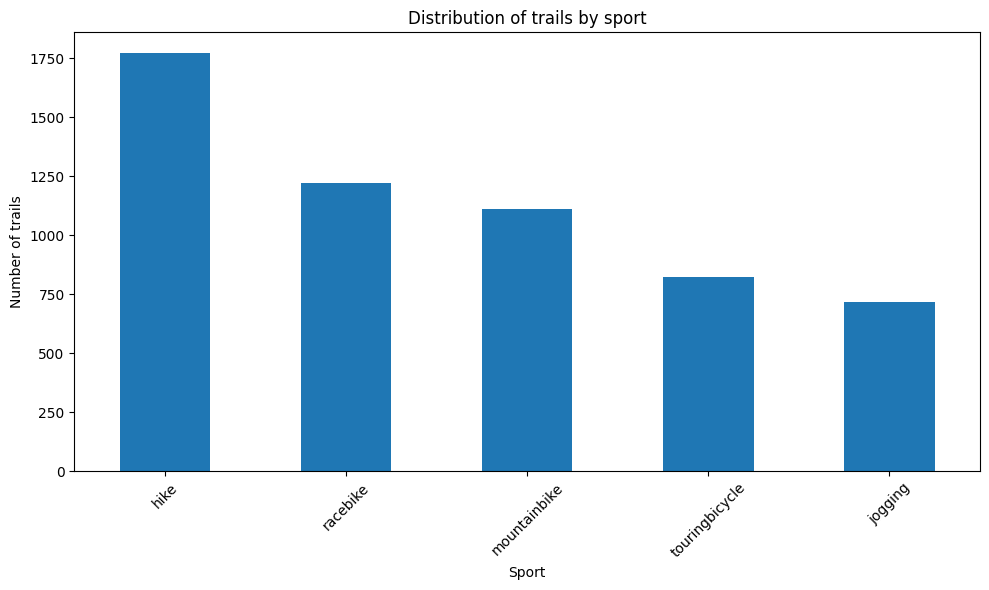

Saved: /content/report/figures/sport_distribution.png


,Number of trails
sport,
hike,1771
racebike,1221
mountainbike,1109
touringbicycle,823
jogging,718


In [51]:

if "sport" in df_plot.columns:
    sport_counts = plot_value_counts(
        df_plot["sport"],
        title="Distribution of trails by sport",
        xlabel="Sport",
        ylabel="Number of trails",
        filename="sport_distribution.png",
        rotation=45,
    )

    display(sport_counts.to_frame("Number of trails"))
    sport_counts.to_csv(TABLE_DIR / "sport_distribution.csv", header=["Number of trails"])

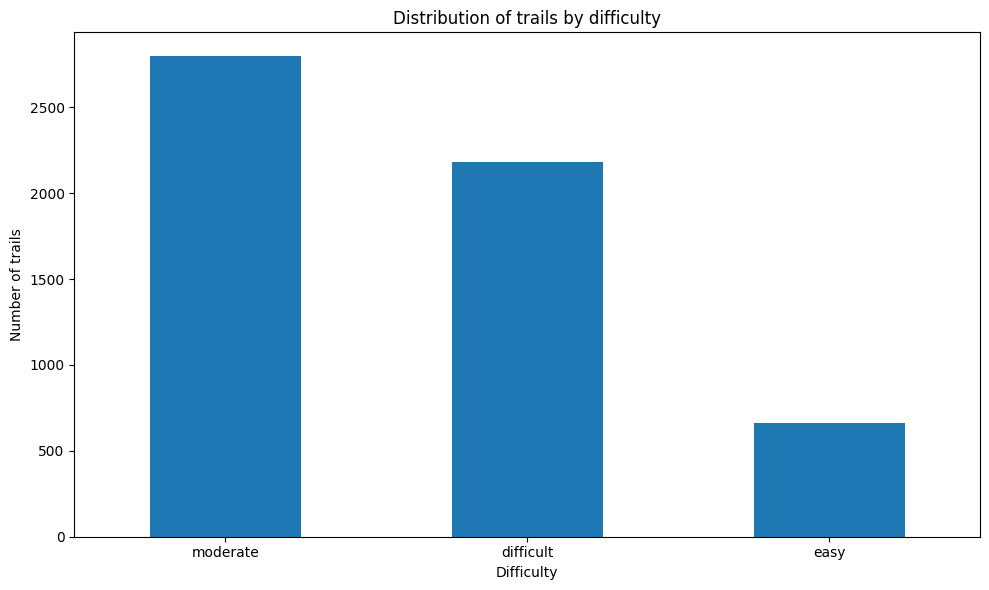

Saved: /content/report/figures/difficulty_distribution.png


,Number of trails
difficulty,
moderate,2797
difficult,2182
easy,663


In [ ]:
if "difficulty" in df_plot.columns:
    difficulty_counts = plot_value_counts(
        df_plot["difficulty"],
        title="Distribution of trails by difficulty",
        xlabel="Difficulty",
        ylabel="Number of trails",
        filename="difficulty_distribution.png",
        rotation=0,
    )

    display(difficulty_counts.to_frame("Number of trails"))
    difficulty_counts.to_csv(TABLE_DIR / "difficulty_distribution.csv", header=["Number of trails"])

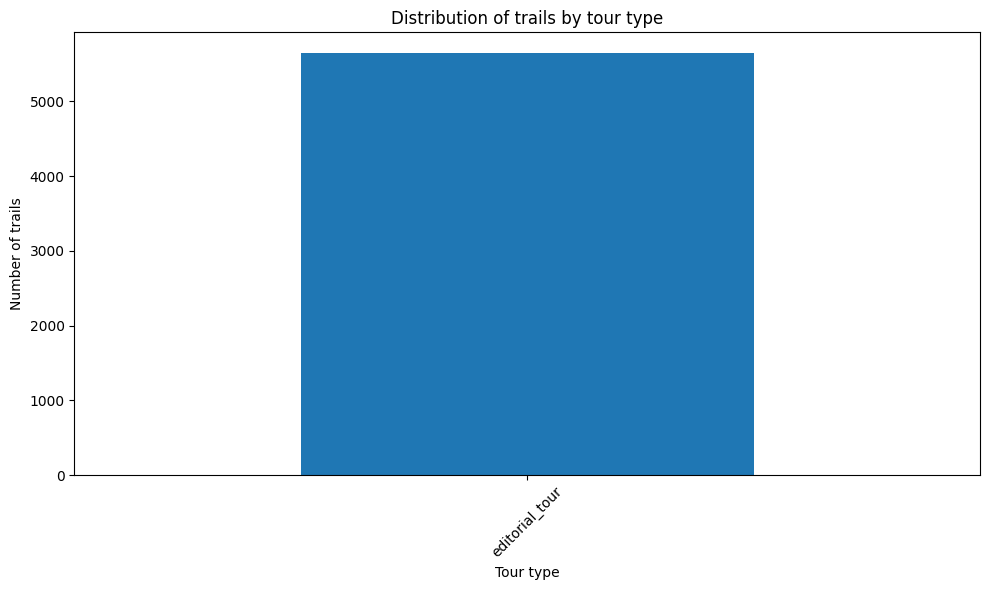

Saved: /content/report/figures/tour_type_distribution.png


,Number of trails
tour_type,
editorial_tour,5642


In [ ]:
if "tour_type" in df_plot.columns:
    tour_type_counts = plot_value_counts(
        df_plot["tour_type"],
        title="Distribution of trails by tour type",
        xlabel="Tour type",
        ylabel="Number of trails",
        filename="tour_type_distribution.png",
        rotation=45,
    )

    display(tour_type_counts.to_frame("Number of trails"))
    tour_type_counts.to_csv(TABLE_DIR / "tour_type_distribution.csv", header=["Number of trails"])

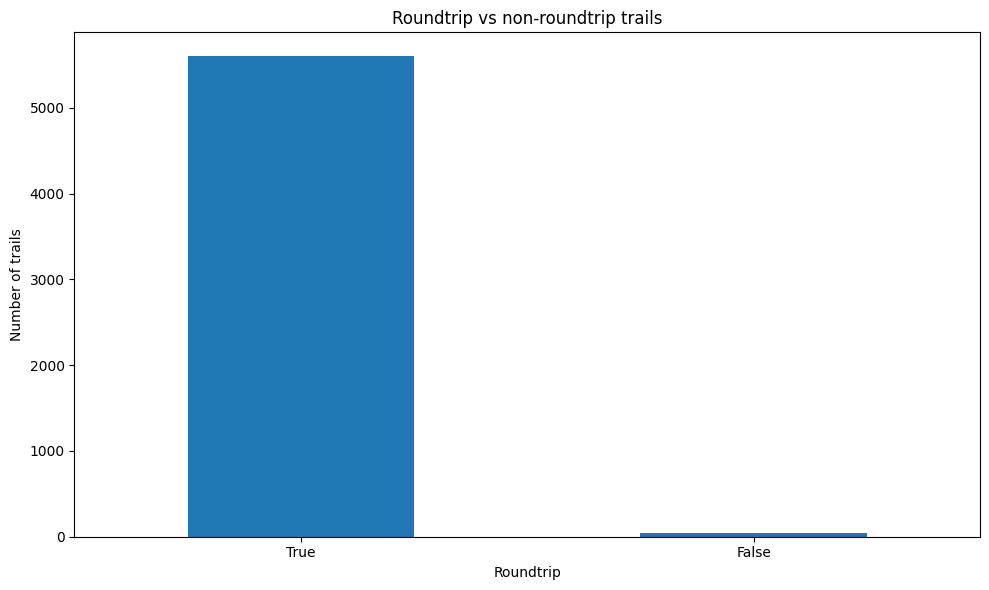

Saved: /content/report/figures/roundtrip_distribution.png


,Number of trails
roundtrip,
True,5599
False,43


In [ ]:
if "roundtrip" in df_plot.columns:
    roundtrip_counts = plot_value_counts(
        df_plot["roundtrip"],
        title="Roundtrip vs non-roundtrip trails",
        xlabel="Roundtrip",
        ylabel="Number of trails",
        filename="roundtrip_distribution.png",
        rotation=0,
    )

    display(roundtrip_counts.to_frame("Number of trails"))
    roundtrip_counts.to_csv(TABLE_DIR / "roundtrip_distribution.csv", header=["Number of trails"])

## 7. Numerical distributions

For distance, duration, elevation, rating count and visitors, the plots use the 99th percentile as a clipping threshold to avoid a few extreme routes dominating the chart.

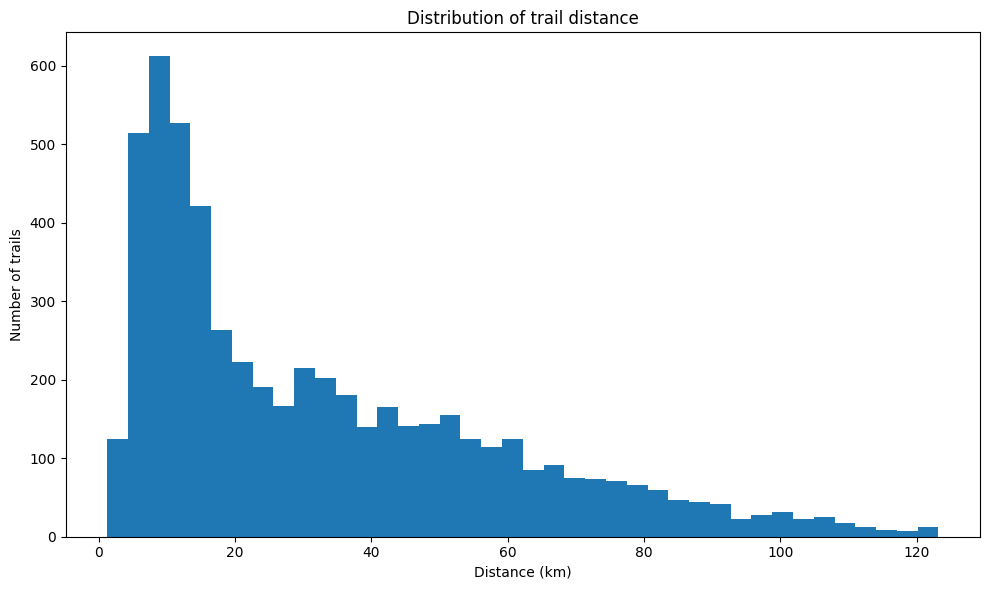

Saved: /content/report/figures/distance_distribution_km.png
count    5585.00
mean       32.81
std        26.31
min         1.27
25%        11.15
50%        24.42
75%        49.18
max       123.18
Name: distance_km, dtype: float64


In [ ]:
if "distance_km" in df_plot.columns:
    distance_data = plot_hist(
        df_plot["distance_km"],
        title="Distribution of trail distance",
        xlabel="Distance (km)",
        ylabel="Number of trails",
        filename="distance_distribution_km.png",
        bins=40,
        clip_quantile=0.99,
    )
    print(distance_data.describe().round(2))

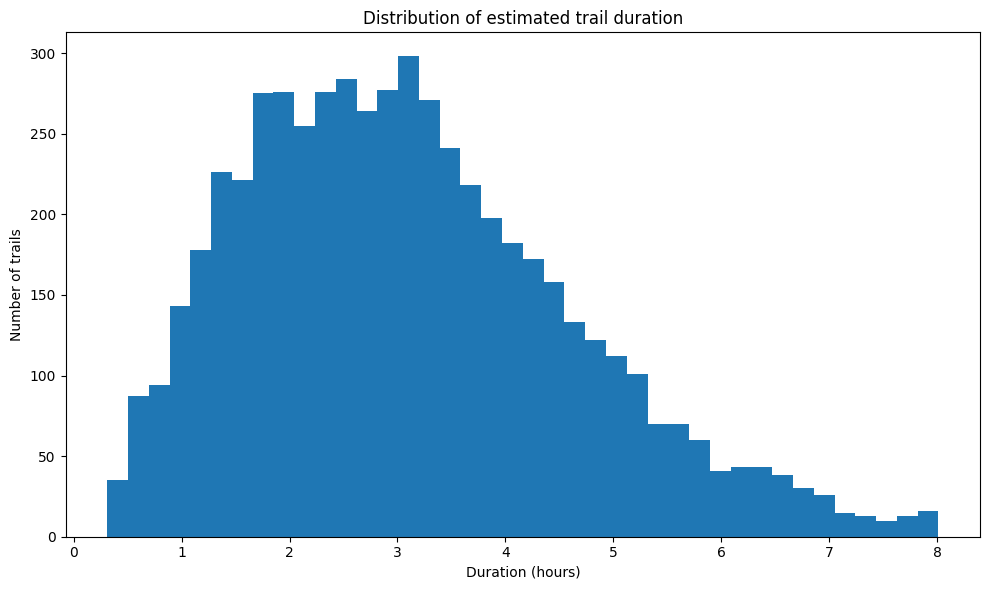

Saved: /content/report/figures/duration_distribution_hours.png
count    5585.00
mean        3.10
std         1.51
min         0.31
25%         1.94
50%         2.93
75%         4.04
max         8.01
Name: duration_h, dtype: float64


In [ ]:
if "duration_h" in df_plot.columns:
    duration_data = plot_hist(
        df_plot["duration_h"],
        title="Distribution of estimated trail duration",
        xlabel="Duration (hours)",
        ylabel="Number of trails",
        filename="duration_distribution_hours.png",
        bins=40,
        clip_quantile=0.99,
    )
    print(duration_data.describe().round(2))

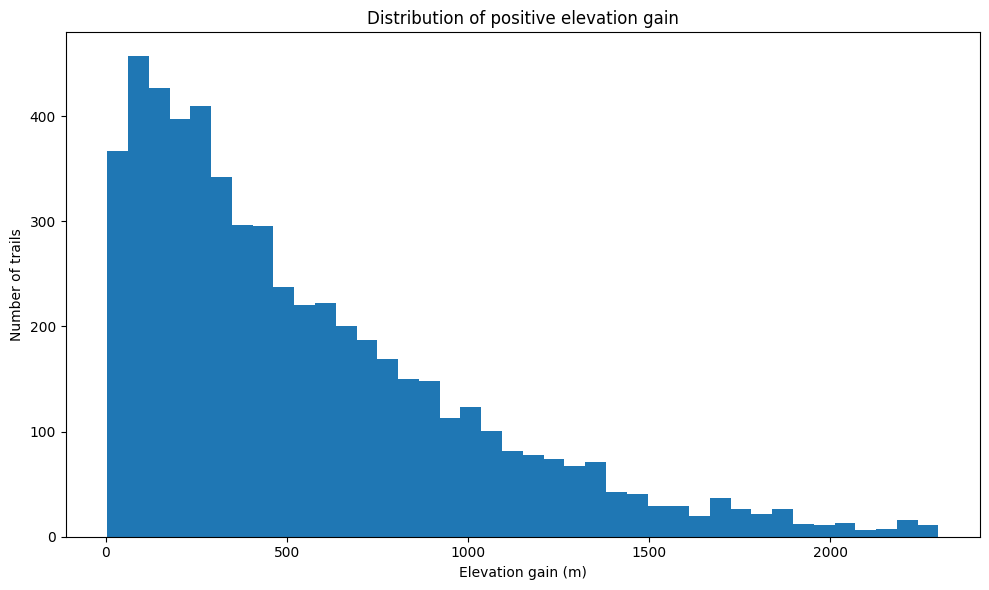

Saved: /content/report/figures/elevation_up_distribution_m.png
count    5585.00
mean      551.82
std       457.28
min         4.51
25%       195.21
50%       424.29
75%       792.01
max      2298.06
Name: elevation_up_m, dtype: float64


In [ ]:
if "elevation_up_m" in df_plot.columns:
    elevation_data = plot_hist(
        df_plot["elevation_up_m"],
        title="Distribution of positive elevation gain",
        xlabel="Elevation gain (m)",
        ylabel="Number of trails",
        filename="elevation_up_distribution_m.png",
        bins=40,
        clip_quantile=0.99,
    )
    print(elevation_data.describe().round(2))

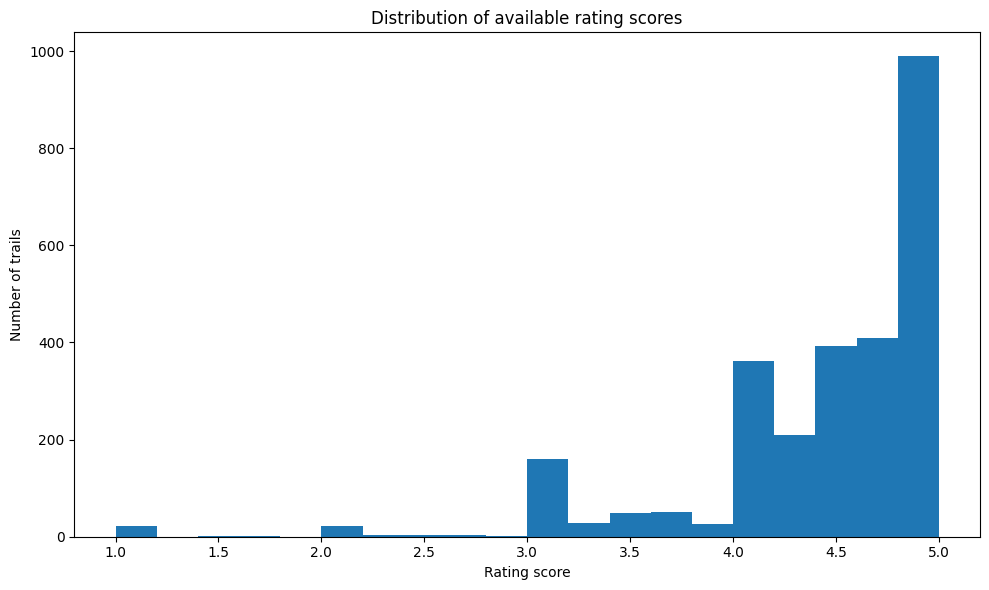

Saved: /content/report/figures/rating_score_distribution.png
count    2735.00
mean        4.42
std         0.68
min         1.00
25%         4.10
50%         4.62
75%         5.00
max         5.00
Name: rating_score, dtype: float64
Missing rating_score values: 2,907


In [ ]:
if "rating_score" in df_plot.columns:
    rating_data = plot_hist(
        df_plot["rating_score"],
        title="Distribution of available rating scores",
        xlabel="Rating score",
        ylabel="Number of trails",
        filename="rating_score_distribution.png",
        bins=20,
        clip_quantile=None,
    )
    print(rating_data.describe().round(2))
    print(f"Missing rating_score values: {df_plot['rating_score'].isna().sum():,}")

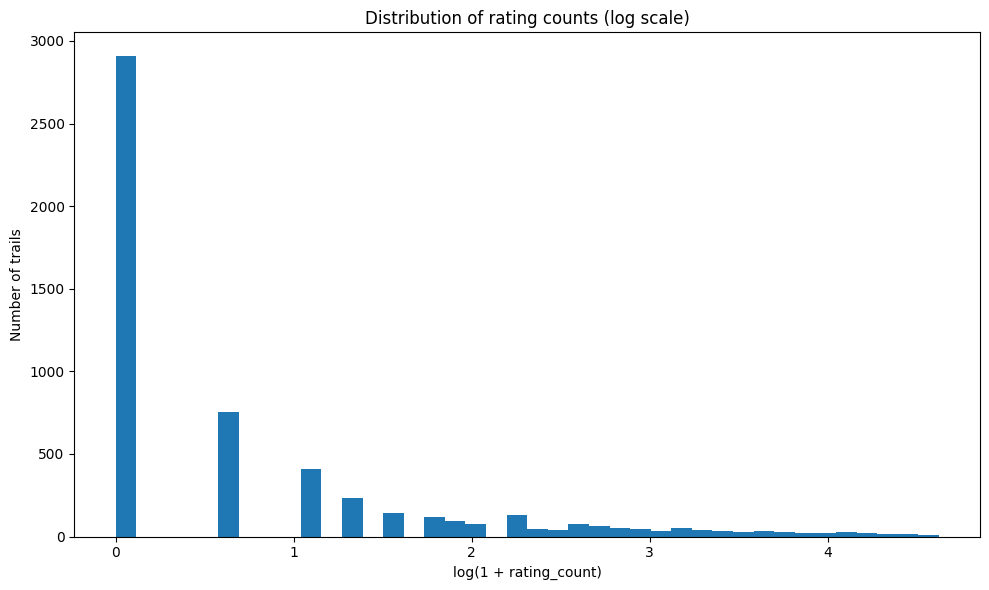

Saved: /content/report/figures/rating_count_log_distribution.png
count    5585.00
mean        0.83
std         1.12
min         0.00
25%         0.00
50%         0.00
75%         1.39
max         4.62
Name: rating_count, dtype: float64


In [ ]:
if "rating_count" in df_plot.columns:
    rating_count_log = np.log1p(pd.to_numeric(df_plot["rating_count"], errors="coerce"))
    rating_count_data = plot_hist(
        rating_count_log,
        title="Distribution of rating counts (log scale)",
        xlabel="log(1 + rating_count)",
        ylabel="Number of trails",
        filename="rating_count_log_distribution.png",
        bins=40,
        clip_quantile=0.99,
    )
    print(rating_count_data.describe().round(2))

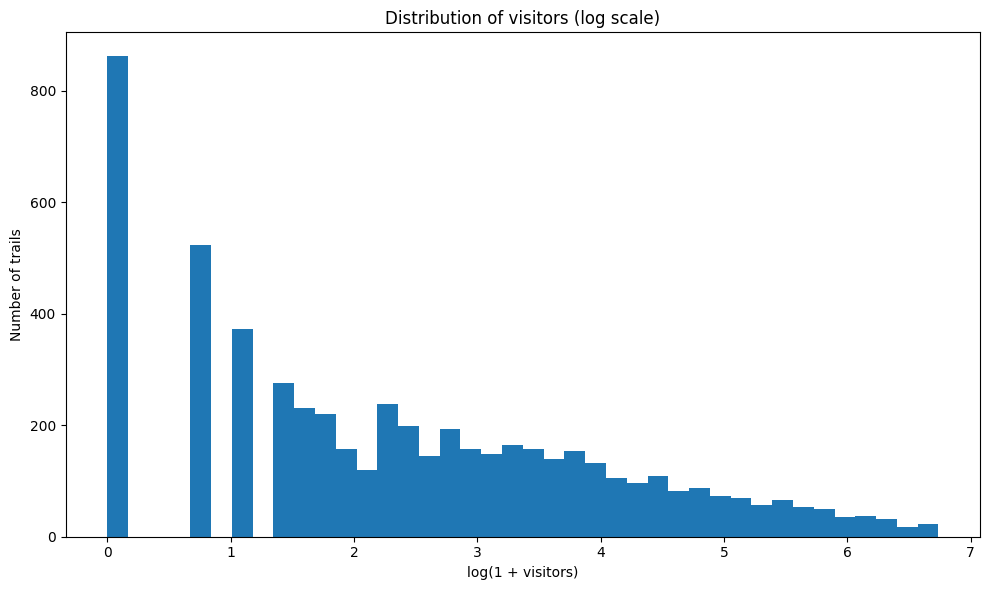

Saved: /content/report/figures/visitors_log_distribution.png
count    5585.00
mean        2.34
std         1.71
min         0.00
25%         1.10
50%         2.20
75%         3.56
max         6.74
Name: visitors, dtype: float64


In [ ]:
if "visitors" in df_plot.columns:
    visitors_log = np.log1p(pd.to_numeric(df_plot["visitors"], errors="coerce"))
    visitors_data = plot_hist(
        visitors_log,
        title="Distribution of visitors (log scale)",
        xlabel="log(1 + visitors)",
        ylabel="Number of trails",
        filename="visitors_log_distribution.png",
        bins=40,
        clip_quantile=0.99,
    )
    print(visitors_data.describe().round(2))

## 8. Regional distribution

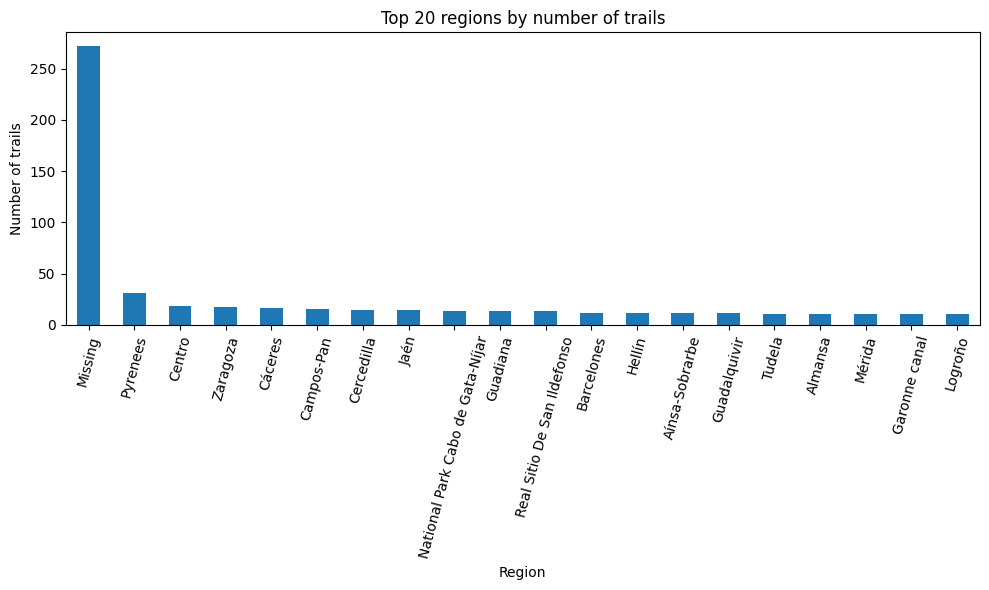

Saved: /content/report/figures/top_regions_distribution.png


,Number of trails
region,
Missing,272
Pyrenees,31
Centro,18
Zaragoza,17
Cáceres,16
Campos-Pan,15
Cercedilla,14
Jaén,14
National Park Cabo de Gata-Níjar,13


In [ ]:
if "region" in df_plot.columns:
    region_counts = plot_value_counts(
        df_plot["region"],
        title="Top 20 regions by number of trails",
        xlabel="Region",
        ylabel="Number of trails",
        filename="top_regions_distribution.png",
        top_n=20,
        rotation=75,
    )

    display(region_counts.to_frame("Number of trails"))
    region_counts.to_csv(TABLE_DIR / "top_regions_distribution.csv", header=["Number of trails"])

## 9. Cross-tabulations for the report

tables to explain the composition of the dataset

difficulty,difficult,easy,moderate
sport,,,
hike,339,347,1085
jogging,378,50,290
mountainbike,473,89,547
racebike,569,94,558
touringbicycle,423,83,317


Saved: /content/report/tables/sport_by_difficulty.csv


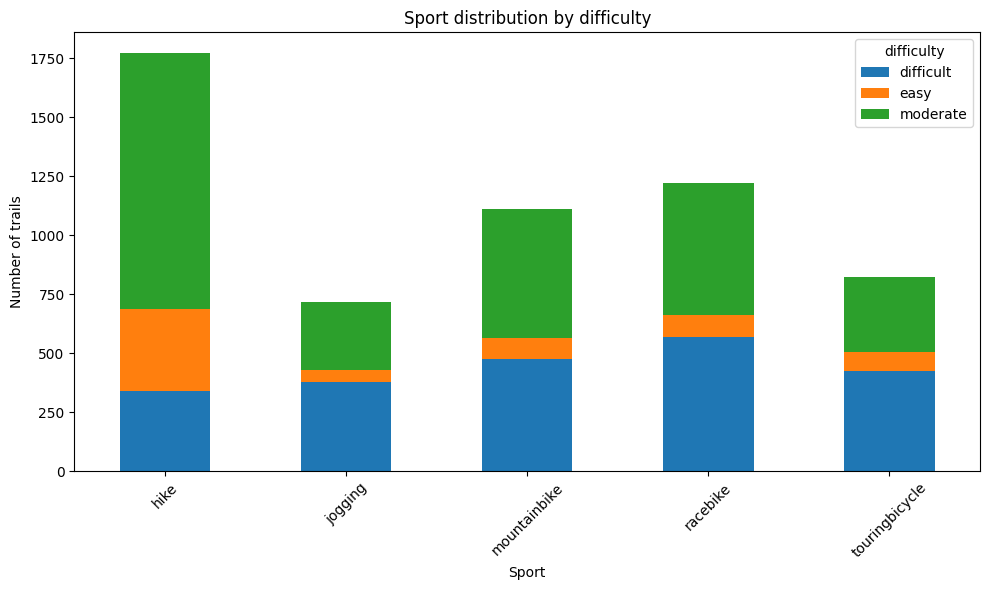

Saved: /content/report/figures/sport_by_difficulty_stacked.png


In [52]:
if {"sport", "difficulty"}.issubset(df_plot.columns):
    sport_difficulty = pd.crosstab(df_plot["sport"], df_plot["difficulty"])
    display(sport_difficulty)

    sport_difficulty.to_csv(TABLE_DIR / "sport_by_difficulty.csv")
    print(f"Saved: {TABLE_DIR / 'sport_by_difficulty.csv'}")

    fig, ax = plt.subplots(figsize=(10, 6))
    sport_difficulty.plot(kind="bar", stacked=True, ax=ax)
    ax.set_title("Sport distribution by difficulty")
    ax.set_xlabel("Sport")
    ax.set_ylabel("Number of trails")
    ax.tick_params(axis="x", rotation=45)
    save_fig("sport_by_difficulty_stacked.png")

## 10. Categories

The `categories` field contains lists, so it needs to be flattened before plotting.

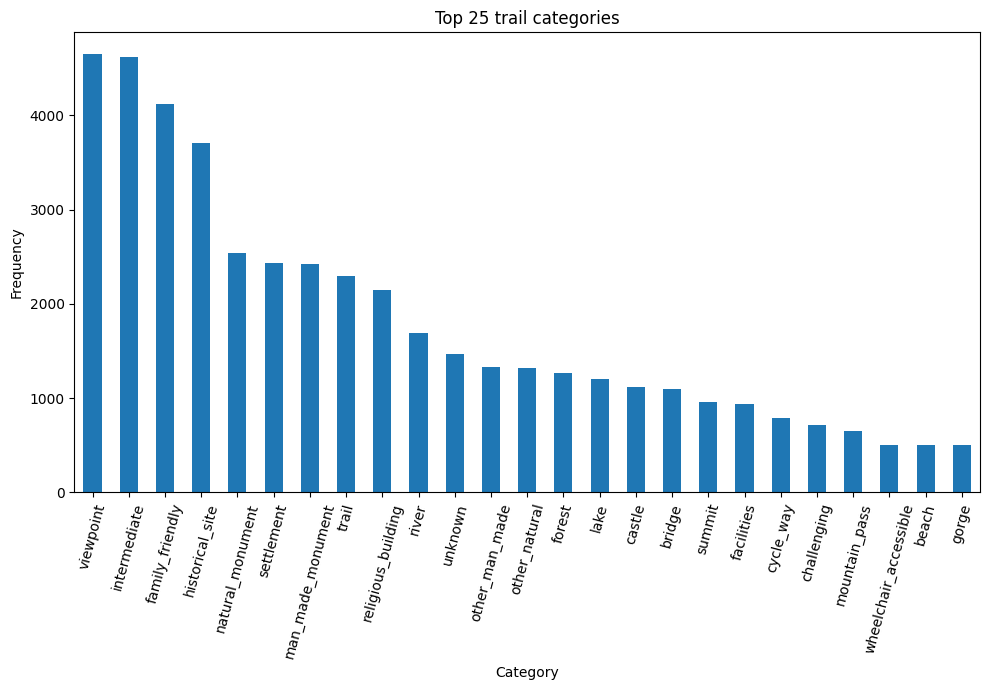

Saved: /content/report/figures/top_categories_distribution.png


,Frequency
viewpoint,4648
intermediate,4623
family_friendly,4121
historical_site,3703
natural_monument,2536
settlement,2432
man_made_monument,2426
trail,2295
religious_building,2142
river,1694


In [ ]:
def ensure_list(value):
    """Convert a value into a list when possible."""
    if isinstance(value, list):
        return value
    if isinstance(value, str):
        try:
            parsed = ast.literal_eval(value)
            if isinstance(parsed, list):
                return parsed
        except Exception:
            return []
    return []


if "categories" in df_plot.columns:
    category_counter = Counter()

    for value in df_plot["categories"].dropna():
        category_counter.update(ensure_list(value))

    category_counts = pd.Series(category_counter).sort_values(ascending=False)

    if not category_counts.empty:
        top_category_counts = category_counts.head(25)

        fig, ax = plt.subplots(figsize=(10, 7))
        top_category_counts.plot(kind="bar", ax=ax)
        ax.set_title("Top 25 trail categories")
        ax.set_xlabel("Category")
        ax.set_ylabel("Frequency")
        ax.tick_params(axis="x", rotation=75)
        save_fig("top_categories_distribution.png")

        display(top_category_counts.to_frame("Frequency"))
        top_category_counts.to_csv(TABLE_DIR / "top_categories_distribution.csv", header=["Frequency"])
    else:
        print("No categories found.")

## 11. Surface and way type composition

The `surfaces` and `way_types` fields are dictionaries containing proportions. The charts below show the average proportion of each type across the dataset.

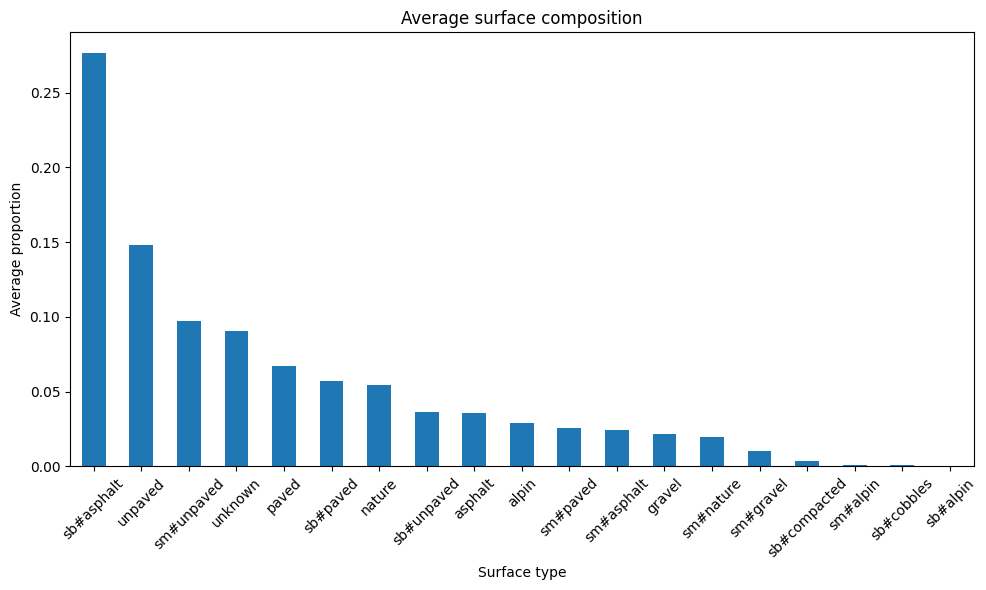

Saved: /content/report/figures/average_surface_composition.png


,Average proportion
sb#asphalt,0.276619
unpaved,0.147858
sm#unpaved,0.097157
unknown,0.090623
paved,0.066863
sb#paved,0.057117
nature,0.054591
sb#unpaved,0.036385
asphalt,0.035552
alpin,0.029148


In [ ]:
def parse_dict_field(value):
    """Convert dictionary-like values into a Python dict."""
    if isinstance(value, dict):
        return value
    if isinstance(value, str):
        try:
            parsed = ast.literal_eval(value)
            if isinstance(parsed, dict):
                return parsed
        except Exception:
            return {}
    return {}


def average_dict_proportions(series):
    accumulator = Counter()
    n_valid = 0

    for value in series.dropna():
        parsed = parse_dict_field(value)
        if parsed:
            for key, val in parsed.items():
                try:
                    accumulator[key] += float(val)
                except Exception:
                    pass
            n_valid += 1

    if n_valid == 0:
        return pd.Series(dtype=float)

    return (pd.Series(accumulator) / n_valid).sort_values(ascending=False)


if "surfaces" in df_plot.columns:
    avg_surfaces = average_dict_proportions(df_plot["surfaces"])

    if not avg_surfaces.empty:
        fig, ax = plt.subplots(figsize=(10, 6))
        avg_surfaces.plot(kind="bar", ax=ax)
        ax.set_title("Average surface composition")
        ax.set_xlabel("Surface type")
        ax.set_ylabel("Average proportion")
        ax.tick_params(axis="x", rotation=45)
        save_fig("average_surface_composition.png")

        display(avg_surfaces.to_frame("Average proportion"))
        avg_surfaces.to_csv(TABLE_DIR / "average_surface_composition.csv", header=["Average proportion"])
    else:
        print("No surface data found.")

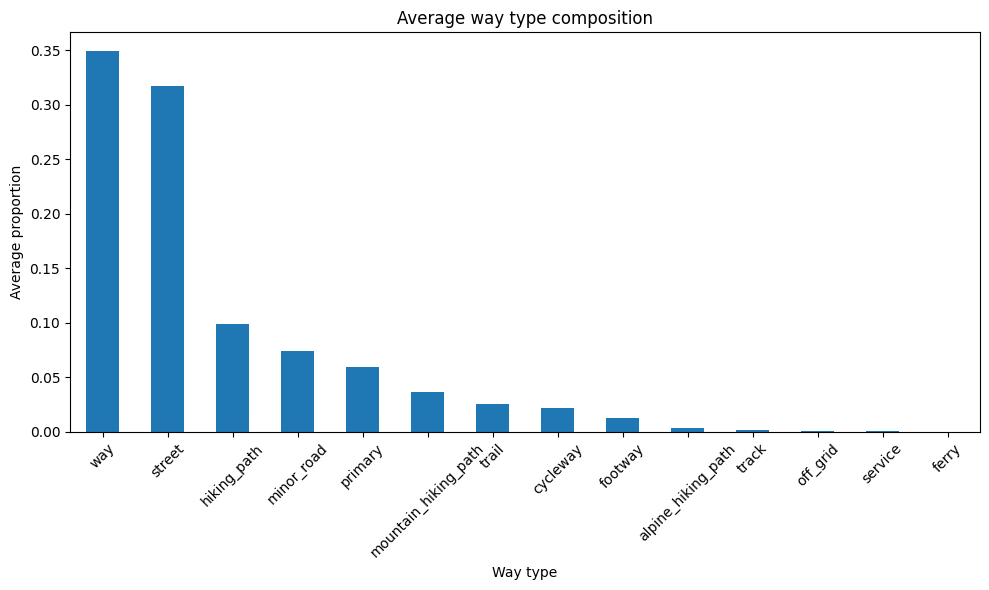

Saved: /content/report/figures/average_way_type_composition.png


,Average proportion
way,0.349158
street,0.316978
hiking_path,0.098586
minor_road,0.073828
primary,0.059262
mountain_hiking_path,0.036682
trail,0.024971
cycleway,0.022061
footway,0.012341
alpine_hiking_path,0.003492


In [ ]:
if "way_types" in df_plot.columns:
    avg_way_types = average_dict_proportions(df_plot["way_types"])

    if not avg_way_types.empty:
        fig, ax = plt.subplots(figsize=(10, 6))
        avg_way_types.plot(kind="bar", ax=ax)
        ax.set_title("Average way type composition")
        ax.set_xlabel("Way type")
        ax.set_ylabel("Average proportion")
        ax.tick_params(axis="x", rotation=45)
        save_fig("average_way_type_composition.png")

        display(avg_way_types.to_frame("Average proportion"))
        avg_way_types.to_csv(TABLE_DIR / "average_way_type_composition.csv", header=["Average proportion"])
    else:
        print("No way type data found.")

## Report Section 2. Dataset Creation and Exploration

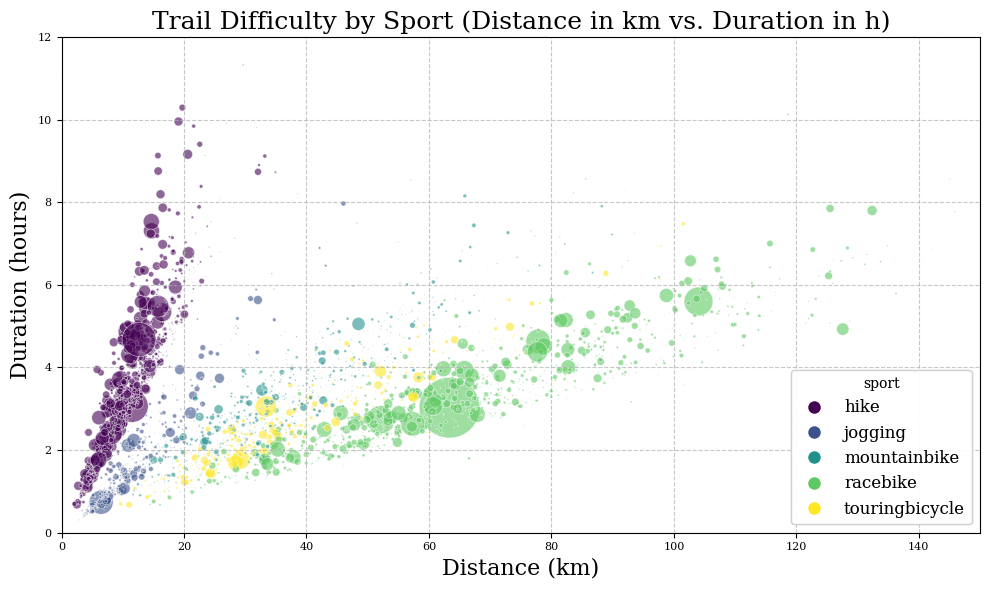

Saved: /content/report/figures/distance_duration_sport_visitors_scatterplot_fixed_color.png


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import matplotlib.font_manager as fm


plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['DejaVu Serif', 'Times New Roman', 'Liberation Serif', 'Bitstream Vera Serif', 'Computer Modern Roman']

if all(col in df_plot.columns for col in ['distance_km', 'duration_h', 'sport', 'visitors']):
    # Scale visitors for marker size (thousands of visitors)
    df_plot['visitors_scaled'] = df_plot['visitors'] / 1000

    # Convert sport to category type and get codes and categories
    sport_cat = df_plot['sport'].astype('category')
    sport_cat = sport_cat.cat.reorder_categories(sorted(sport_cat.cat.categories), ordered=True)
    sport_codes = sport_cat.cat.codes

    fig, ax = plt.subplots(figsize=(10, 6))
    scatter = ax.scatter(
        x=df_plot['distance_km'],
        y=df_plot['duration_h'],
        c=sport_codes,
        cmap='viridis',
        s=df_plot['visitors_scaled'] * 100,
        alpha=0.6,
        edgecolors='w',
        linewidths=0.5
    )

    # Legend for sport colors using original category names
    unique_sport_codes = np.unique(sport_codes)
    sport_names = [sport_cat.cat.categories[code] for code in unique_sport_codes]


    cmap = plt.get_cmap('viridis')
    # Get a color for each unique sport code, normalized by the number of categories
    colors = [cmap(code / (len(sport_cat.cat.categories) - 1)) for code in unique_sport_codes]

    # Create proxy artists for the legend
    legend_handles = [Line2D([0], [0], marker='o', color='w', label=name,
                             markerfacecolor=color, markersize=10)
                      for name, color in zip(sport_names, colors)]

    legend1 = ax.legend(handles=legend_handles, title='sport', fontsize=12)
    ax.add_artist(legend1)

    ax.set_title('Trail Difficulty by Sport (Distance in km vs. Duration in h)', fontsize=18)
    ax.set_xlabel('Distance (km)', fontsize=16)
    ax.set_ylabel('Duration (hours)', fontsize=16)
    ax.set_xlim(0, 150) # Set x-axis limit to 150 km for visibility
    ax.set_ylim(0, 12)  # Set y-axis limit to 12 hours for visibility
    ax.tick_params(axis='both', which='major', labelsize=8)
    ax.grid(True, linestyle='--', alpha=0.7)

    save_fig('distance_duration_sport_visitors_scatterplot_fixed_color.png')
else:
    print("Required columns for plotting (distance_km, duration_h, sport, visitors) not found.")